# Public Sales Performance Analysis

This notebook presents an anonymized analysis of ERP order records from an industrial automation company.

To protect confidential business information, the analysis uses only public summary datasets containing anonymized labels, percentage shares, and index values. Original employee names, customer names, product details, and financial amounts are not included.

In [1]:
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from IPython.display import display


# Upload the public_data.zip file
uploaded = files.upload()

zip_files = [
    file_name
    for file_name in uploaded.keys()
    if file_name.lower().endswith(".zip")
]

if not zip_files:
    raise FileNotFoundError(
        "Upload the public_data.zip file."
    )

zip_name = zip_files[0]


# Extract the public datasets
public_folder = "data/public"
os.makedirs(public_folder, exist_ok=True)

with zipfile.ZipFile(zip_name, "r") as zip_file:
    zip_file.extractall(public_folder)


# Load public datasets
company_performance = pd.read_csv(
    f"{public_folder}/company_performance_indices.csv"
)

employee_order_share = pd.read_csv(
    f"{public_folder}/employee_order_share.csv"
)

customer_concentration = pd.read_csv(
    f"{public_folder}/customer_concentration.csv"
)

monthly_distribution = pd.read_csv(
    f"{public_folder}/monthly_order_distribution.csv"
)

business_division_share = pd.read_csv(
    f"{public_folder}/business_division_order_share.csv"
)

employee_large_order = pd.read_csv(
    f"{public_folder}/employee_large_order_concentration.csv"
)


# Confirm that the datasets were loaded
datasets = {
    "Company performance": company_performance,
    "Employee order share": employee_order_share,
    "Customer concentration": customer_concentration,
    "Monthly distribution": monthly_distribution,
    "Business division share": business_division_share,
    "Employee large-order concentration": employee_large_order
}

for dataset_name, dataset in datasets.items():
    print(f"{dataset_name}: {dataset.shape[0]} rows × {dataset.shape[1]} columns")


print("\nCompany performance data:")
display(company_performance.head())

print("\nEmployee order-share data:")
display(employee_order_share.head())

print("\nCustomer-concentration data:")
display(customer_concentration.head())

Saving public_data.zip to public_data.zip
Company performance: 6 rows × 4 columns
Employee order share: 5 rows × 4 columns
Customer concentration: 3 rows × 5 columns
Monthly distribution: 6 rows × 4 columns
Business division share: 3 rows × 3 columns
Employee large-order concentration: 5 rows × 4 columns

Company performance data:


,year,total_order_value_index,order_count_index,average_order_value_index
0,2020,100.000000,100.000000,100.000000
1,2021,102.312916,76.530612,133.688877
2,2022,122.805738,97.959184,125.364190
3,2023,101.868059,89.285714,114.092227
4,2024,49.315293,83.163265,59.299370



Employee order-share data:


,public_name,share_2024,share_2025,share_2026
0,Employee A,36.256752,38.486852,53.454112
1,Employee B,0.000000,0.188254,18.001095
2,Employee C,0.055023,9.714335,16.465471
3,Employee D,11.194255,1.971617,11.429393
4,Employee E,0.426371,11.499017,0.649930



Customer-concentration data:


,year,top1_share,top3_share,top5_share,customer_count
0,2024,24.469708,52.260763,65.914153,32
1,2025,30.786484,52.469163,66.660642,37
2,2026,29.420021,49.397557,65.126266,44


## Public Visualizations

The following visualizations use only anonymized labels, percentage shares, and index values. No original employee names, customer names, or financial amounts are included.

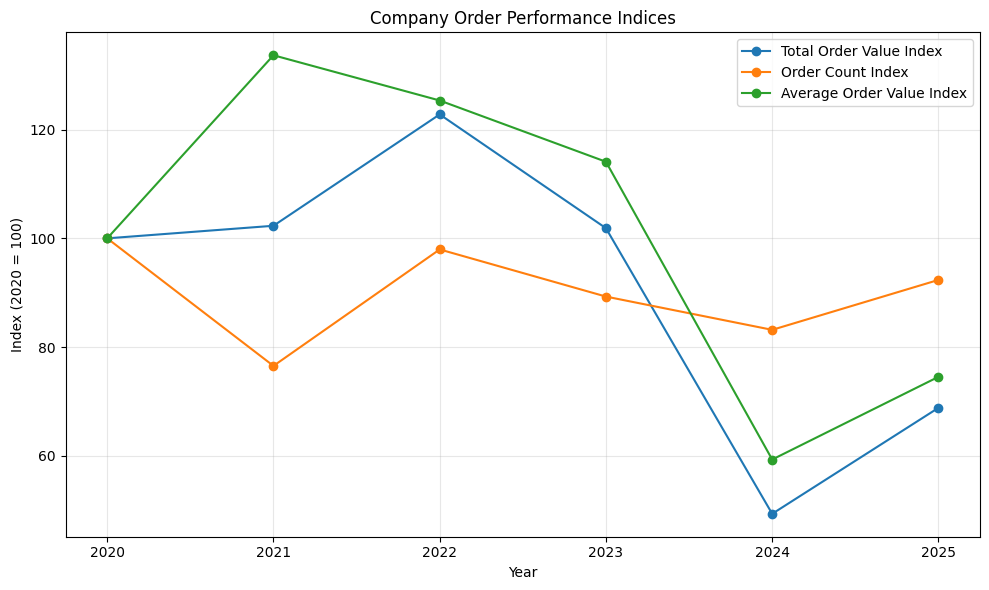

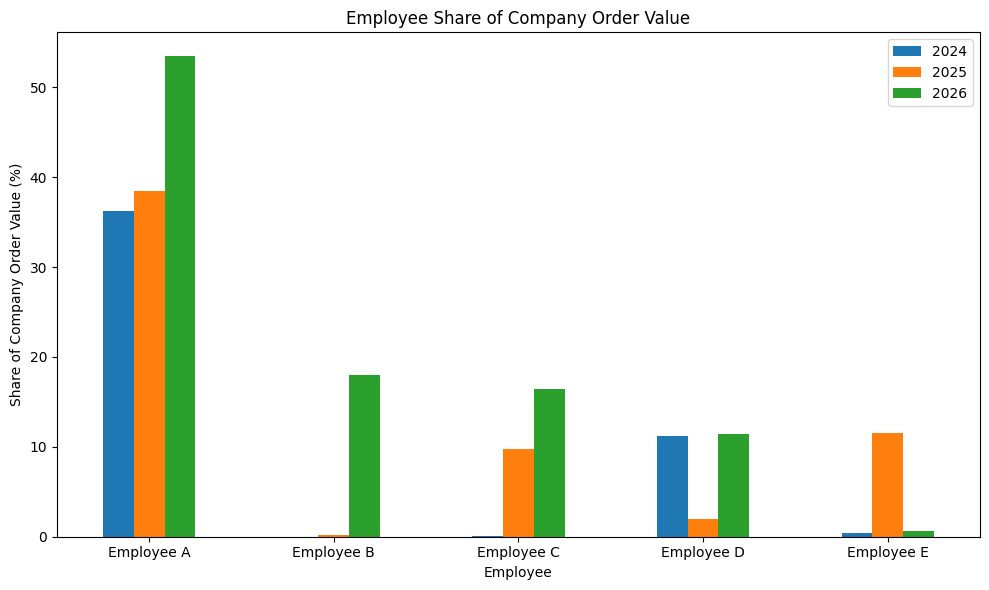

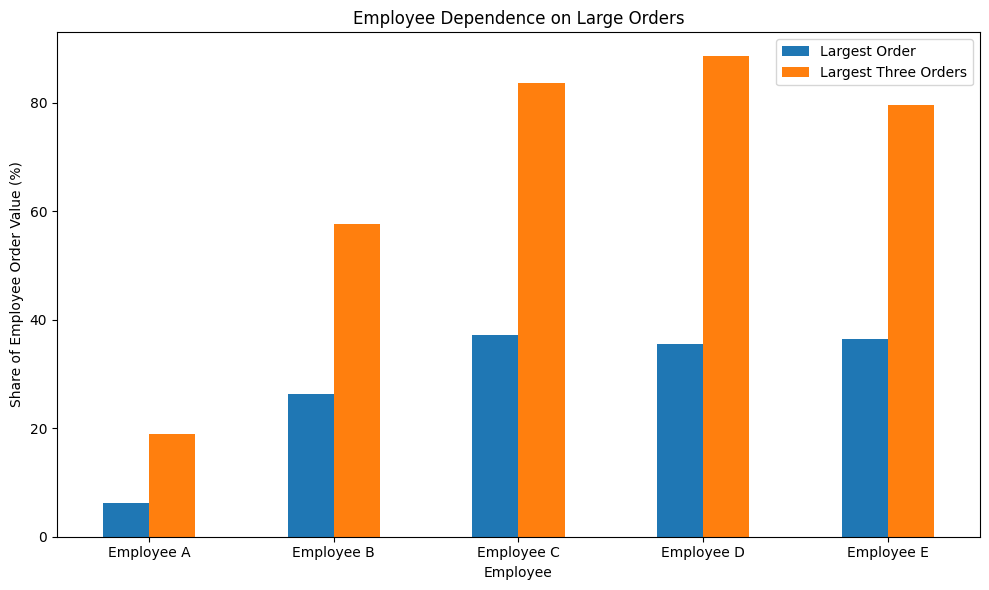

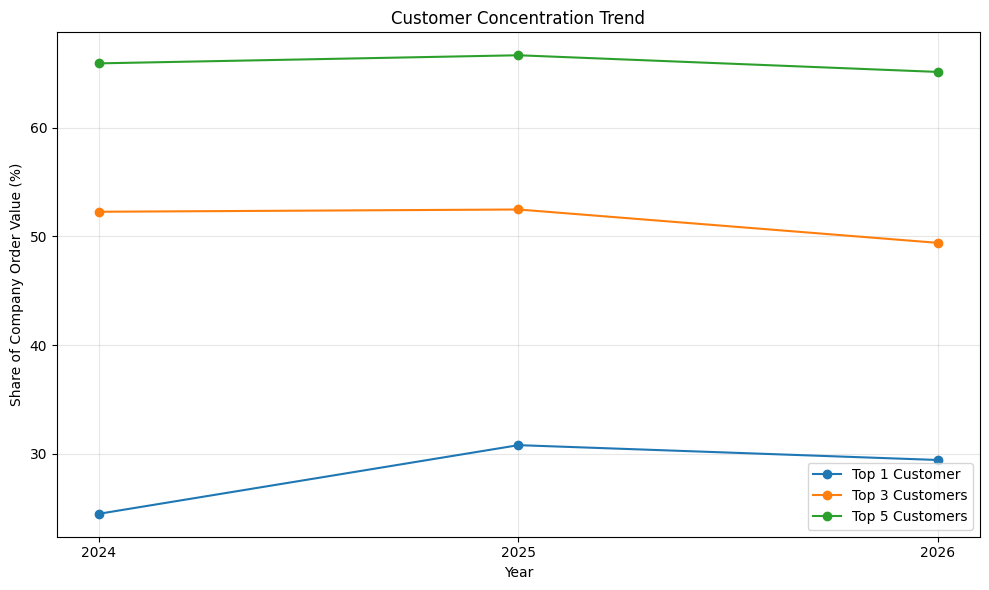

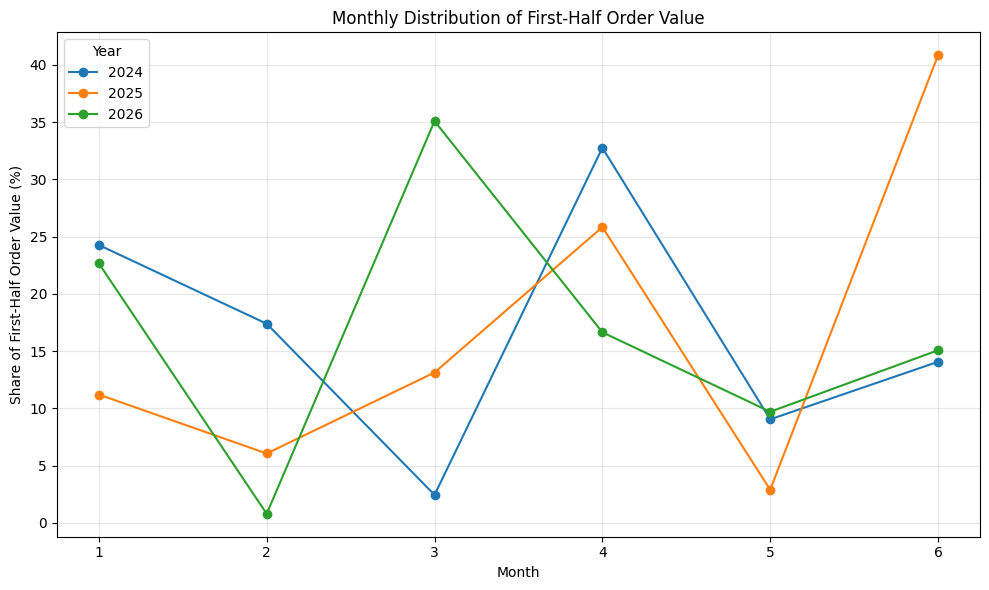

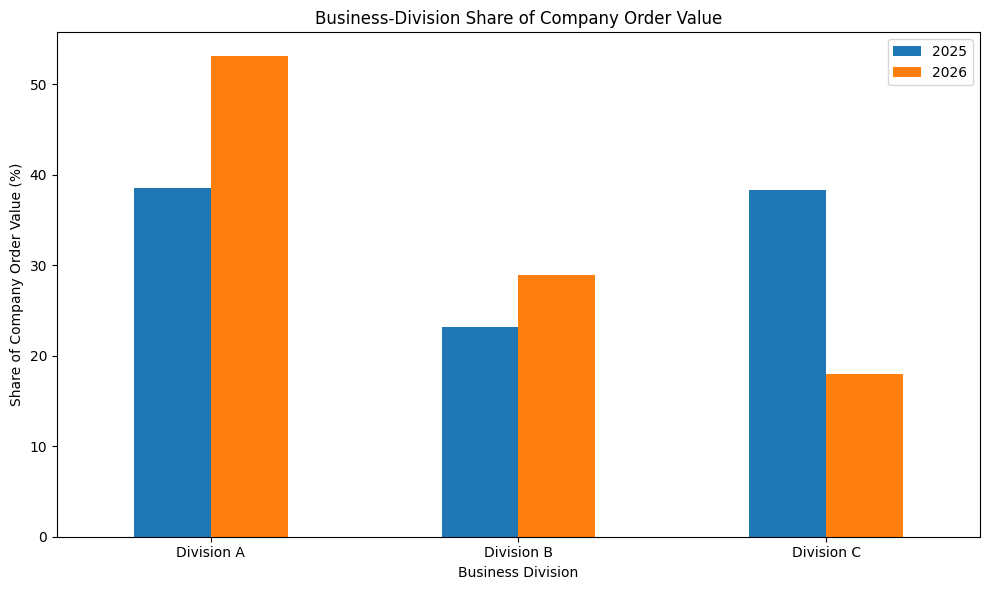

Saved public charts:
- business_division_order_share.png
- company_order_performance_indices.png
- customer_concentration_trend.png
- employee_large_order_concentration.png
- employee_order_share.png
- monthly_order_value_distribution.png


In [2]:
import os
import matplotlib.pyplot as plt

charts_folder = "charts"
os.makedirs(charts_folder, exist_ok=True)


# 1. Company performance indices
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    company_performance["year"],
    company_performance["total_order_value_index"],
    marker="o",
    label="Total Order Value Index"
)

ax.plot(
    company_performance["year"],
    company_performance["order_count_index"],
    marker="o",
    label="Order Count Index"
)

ax.plot(
    company_performance["year"],
    company_performance["average_order_value_index"],
    marker="o",
    label="Average Order Value Index"
)

ax.set_title("Company Order Performance Indices")
ax.set_xlabel("Year")
ax.set_ylabel("Index (2020 = 100)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    f"{charts_folder}/company_order_performance_indices.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 2. Employee share of company order value
employee_share_plot = employee_order_share.set_index("public_name")[
    ["share_2024", "share_2025", "share_2026"]
]

ax = employee_share_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Employee Share of Company Order Value")
ax.set_xlabel("Employee")
ax.set_ylabel("Share of Company Order Value (%)")
ax.legend(["2024", "2025", "2026"])
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(
    f"{charts_folder}/employee_order_share.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 3. Employee dependence on large orders
employee_large_plot = employee_large_order.set_index("public_name")[
    ["top1_share", "top3_share"]
]

ax = employee_large_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Employee Dependence on Large Orders")
ax.set_xlabel("Employee")
ax.set_ylabel("Share of Employee Order Value (%)")
ax.legend(["Largest Order", "Largest Three Orders"])
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(
    f"{charts_folder}/employee_large_order_concentration.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 4. Customer concentration trend
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    customer_concentration["year"],
    customer_concentration["top1_share"],
    marker="o",
    label="Top 1 Customer"
)

ax.plot(
    customer_concentration["year"],
    customer_concentration["top3_share"],
    marker="o",
    label="Top 3 Customers"
)

ax.plot(
    customer_concentration["year"],
    customer_concentration["top5_share"],
    marker="o",
    label="Top 5 Customers"
)

ax.set_title("Customer Concentration Trend")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Company Order Value (%)")
ax.set_xticks(customer_concentration["year"])
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    f"{charts_folder}/customer_concentration_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 5. Monthly order-value distribution
month_column = monthly_distribution.columns[0]

monthly_plot = monthly_distribution.set_index(month_column)

fig, ax = plt.subplots(figsize=(10, 6))

for column in monthly_plot.columns:
    ax.plot(
        monthly_plot.index,
        monthly_plot[column],
        marker="o",
        label=str(column)
    )

ax.set_title("Monthly Distribution of First-Half Order Value")
ax.set_xlabel("Month")
ax.set_ylabel("Share of First-Half Order Value (%)")
ax.legend(title="Year")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    f"{charts_folder}/monthly_order_value_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 6. Business-division order share
division_plot = business_division_share.set_index("public_name")[
    ["share_2025", "share_2026"]
]

ax = division_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Business-Division Share of Company Order Value")
ax.set_xlabel("Business Division")
ax.set_ylabel("Share of Company Order Value (%)")
ax.legend(["2025", "2026"])
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(
    f"{charts_folder}/business_division_order_share.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


print("Saved public charts:")

for file_name in sorted(os.listdir(charts_folder)):
    print("-", file_name)

## Interpretation of Results

### Company Performance

The company’s total order-value index reached its highest level in 2022, declined sharply in 2024, and partially recovered in 2025.

The order-count index declined less than the total order-value index. This suggests that the 2024 decline was influenced more by smaller average order sizes than by a major reduction in the number of orders.

### Employee Performance Patterns

Employee A accounted for the largest share of company order value during the first half of 2026.

However, the employees showed different performance patterns. Some employees generated results through many moderate-sized orders, while others depended on a smaller number of high-value orders.

This demonstrates why employee performance should not be evaluated using total order value alone.

### Dependence on Large Orders

Employee A had the lowest dependence on the largest three orders, indicating that performance was distributed across a relatively large number of orders.

Several other employees generated approximately 80% or more of their order value from their largest three orders. Their results may therefore be more sensitive to the success or failure of a small number of major contracts.

### Customer Concentration

The largest five customers accounted for approximately 65% of company order value in each comparison year.

Although the number of customers increased from 32 in 2024 to 44 in 2026, the company continued to depend substantially on a limited number of major customers.

The decrease in top-three customer concentration suggests a modest improvement in customer diversification.

### Monthly Order Distribution

The month with the highest share of first-half order value changed across the three years:

- April in 2024
- June in 2025
- March in 2026

This indicates that the dataset does not show a consistent monthly seasonal pattern. Monthly peaks may instead be influenced by individual large orders.

### Business-Division Performance

Division A increased its share of company order value between 2025 and 2026, while Division C’s share declined.

However, these results should be interpreted cautiously because the company’s division names and organizational structure may have changed over time.

## Conclusion

The analysis shows that company and employee performance cannot be understood through a single metric.

Total order value, order count, average order size, dependence on large orders, customer concentration, and customer diversity reveal different aspects of business performance.

The results also demonstrate the importance of fair period comparisons, careful interpretation, and protection of confidential business information.

In [3]:
import shutil
from google.colab import files

shutil.make_archive(
    "public_charts",
    "zip",
    "charts"
)

files.download("public_charts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>